# Synthetic 8x8 GMM testbed


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "sampler_research" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))

from sampler_research.gmm import sample_iid_gmm
from sampler_research.io import load_npz, load_sampler_arrays
from sampler_research.plotting import (
    plot_component_fields,
    plot_field_pair,
    plot_mu_slices,
)
from sampler_research.toy import Phase1ToyConfig


## Load the two toy datasets


In [2]:
OUTPUT_DATA_DIR = PROJECT_ROOT / "outputs" / "data"

homo_config = Phase1ToyConfig(use_heteroscedastic_sigma=False)
hetero_config = Phase1ToyConfig(use_heteroscedastic_sigma=True)
homo_path = OUTPUT_DATA_DIR / homo_config.output_filename
hetero_path = OUTPUT_DATA_DIR / hetero_config.output_filename

missing = [path for path in (homo_path, hetero_path) if not path.exists()]
if missing:
    missing_names = ", ".join(path.name for path in missing)
    raise FileNotFoundError(
        f"Missing generated toy data: {missing_names}. "
        "Run `python scripts/generate_toy_data.py` from the repository root."
    )

homo = load_npz(homo_path)
hetero = load_npz(hetero_path)

for label, toy, config in (
    ("homoscedastic", homo, homo_config),
    ("heteroscedastic", hetero, hetero_config),
):
    print(f"{label:16s} variant={toy['variant_name'].item():24s} sigma_mode={toy['sigma_mode'].item()}")
    print(f"                 pi_mode={toy['pi_mode'].item()}  alpha={toy['dirichlet_alpha'].item():.1f}  pi_floor={config.pi_floor:.3f}")
    print(
        f"                 pi range [{toy['pi'].min():.4f}, {toy['pi'].max():.4f}]"
        f"  sigma range [{toy['sigma'].min():.3f}, {toy['sigma'].max():.3f}]"
    )

assert np.array_equal(homo["pi"], hetero["pi"])
assert np.array_equal(homo["mu"], hetero["mu"])
print("shared pi/mu across the two toys:", True)
print("no truth field:", "truth" not in homo, "| no raw_pi:", "raw_pi" not in homo)

sampler_arrays = load_sampler_arrays(homo_path)
for key in ("pi", "mu", "sigma", "coords"):
    assert np.array_equal(sampler_arrays[key], homo[key])
print(f"loaded {homo_path.name} and {hetero_path.name}; sampler-facing arrays OK")


homoscedastic    variant=phase_1_homoscedastic    sigma_mode=fixed
                 pi_mode=random_soft_dirichlet  alpha=4.0  pi_floor=0.050
                 pi range [0.0931, 0.5806]  sigma range [1.000, 1.000]
heteroscedastic  variant=phase_1_heteroscedastic  sigma_mode=heteroscedastic_spatial
                 pi_mode=random_soft_dirichlet  alpha=4.0  pi_floor=0.050
                 pi range [0.0931, 0.5806]  sigma range [0.641, 1.490]
shared pi/mu across the two toys: True
no truth field: True | no raw_pi: True
loaded phase_1_homoscedastic.npz and phase_1_heteroscedastic.npz; sampler-facing arrays OK


## Component mean fields


sheet base levels (peak_height + offsets): [11.5, 10.0, 9.0, 10.5]


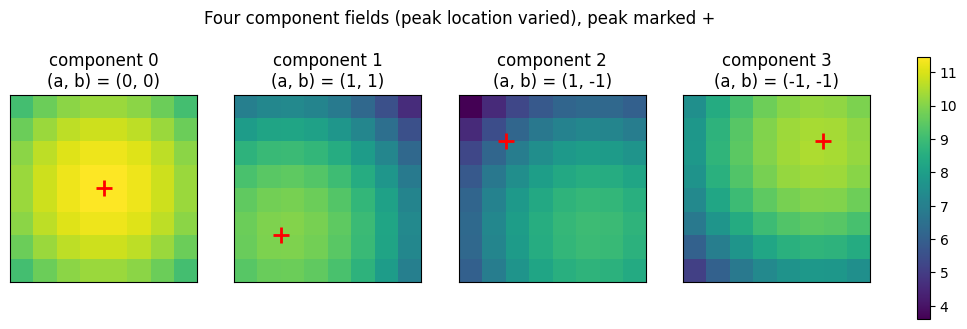

In [3]:
extent = [homo_config.x_min, homo_config.x_max, homo_config.y_min, homo_config.y_max]
print("sheet base levels (peak_height + offsets):",
      (homo_config.peak_height + homo_config.peak_height_offsets).tolist())
plot_component_fields(homo["component_fields"], homo_config.peak_offsets, extent)
plt.show()

### `mu` at fixed label index


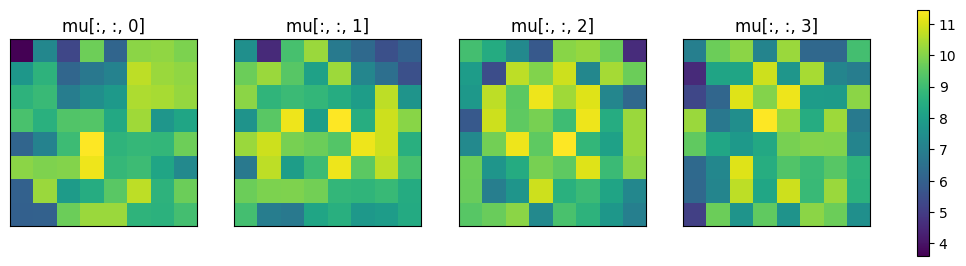

In [4]:
plot_mu_slices(homo["mu"])
plt.show()

## Homoscedastic toy: mixture weights and an iid draw


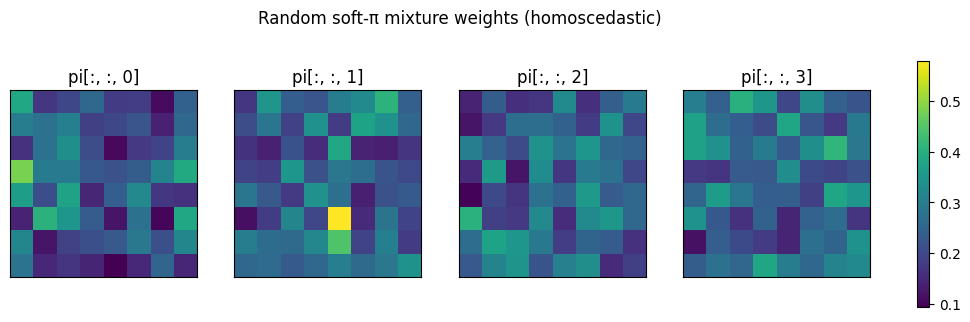

In [5]:
fig, axes = plt.subplots(1, homo_config.k, figsize=(3 * homo_config.k, 3.2), sharex=True, sharey=True)
weight_vmin, weight_vmax = homo["pi"].min(), homo["pi"].max()
for k, ax in enumerate(axes):
    im = ax.imshow(
        homo["pi"][:, :, k], origin="lower", extent=extent,
        vmin=weight_vmin, vmax=weight_vmax, cmap="viridis",
    )
    ax.set_title(f"pi[:, :, {k}]")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.025)
fig.suptitle("Random soft-π mixture weights (homoscedastic)", y=1.04)
plt.show()

### iid draw and one smooth reference sheet


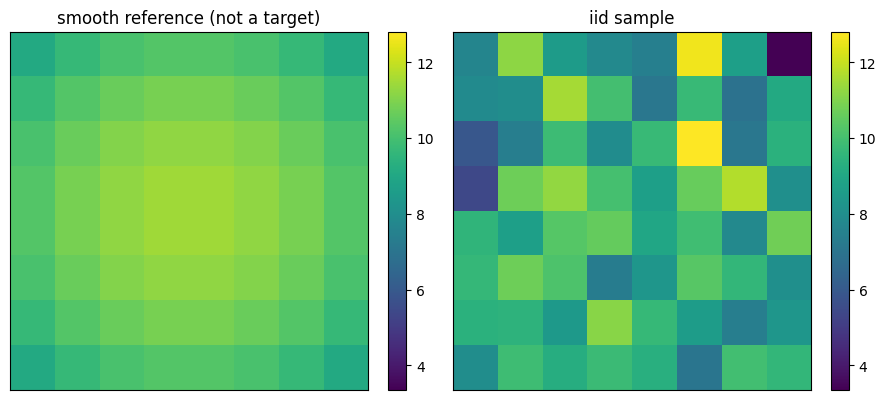

In [6]:
sample_rng = np.random.default_rng(homo_config.seed + 1)
iid_sample, _ = sample_iid_gmm(homo["pi"], homo["mu"], homo["sigma"], sample_rng)
reference_surface = homo["component_fields"][:, :, 0]

plot_field_pair(reference_surface, iid_sample, ("smooth reference (not a target)", "iid sample"))
plt.show()

## Heteroscedastic toy


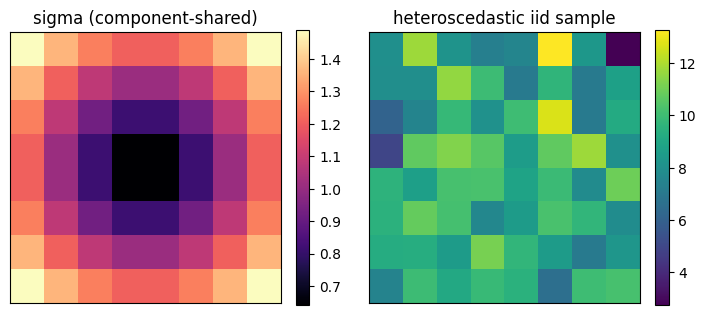

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6))

im = axes[0].imshow(hetero["sigma"][:, :, 0], origin="lower", extent=extent, cmap="magma")
axes[0].set_title("sigma (component-shared)")
axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(im, ax=axes[0], fraction=0.046)

hetero_rng = np.random.default_rng(hetero_config.seed + 1)
hetero_iid, _ = sample_iid_gmm(hetero["pi"], hetero["mu"], hetero["sigma"], hetero_rng)
im2 = axes[1].imshow(hetero_iid, origin="lower", extent=extent, cmap="viridis")
axes[1].set_title("heteroscedastic iid sample")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im2, ax=axes[1], fraction=0.046)
plt.show()